In [13]:
import time
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import schwabdev as sd
import time as tm
import zarr
import shutil
import os

import warnings

warnings.filterwarnings('ignore', message="The data type .* does not have a Zarr V3 specification.*")
warnings.filterwarnings('ignore', message="Consolidated metadata is currently not part in the Zarr format 3 specification.*")

pd.options.display.float_format = '{:,.2f}'.format

from main_classes.DataManager import DataManager as DM
from utility.lib_apiManagment import create_client as CC

dm = DM()
zarr_store = xr.open_dataset(dm.hot_db_path)
zarr_store

<xarray.Dataset> Size: 23GB
Dimensions:  (day: 54, ident: 5094, fVar: 18, time: 288, qVar: 36)
Coordinates:
  * fVar     (fVar) <U28 2kB 'assetSubType' 'ssid' ... 'quote.closePrice'
  * qVar     (qVar) <U29 4kB 'reference.htbRate' ... 'quote.postMarketPercent...
  * day      (day) <U10 2kB '2025-09-14' '2025-09-15' ... '2025-11-16'
  * ident    (ident) <U5 102kB 'A' 'AA' 'AACB' 'AACI' ... 'ZYBT' 'ZYME' 'ZYXI'
  * time     (time) <U5 6kB '00:00' '00:05' '00:10' ... '23:45' '23:50' '23:55'
Data variables:
    1d       (day, ident, fVar) float64 40MB ...
    5m       (day, time, ident, qVar) float64 23GB ...

In [50]:
def clean_5m_display(date,time,ident):
    data = zarr_store['5m'].sel(day=date,ident=ident)
    df = data.sel(time=time).to_dataframe()
    df['5m'] = df['5m'].astype(object)
    time_rows = [
        'extended.tradeTime',
        'extended.quoteTime',
        'quote.askTime',
        'quote.bidTime',
        'quote.tradeTime',
        'quote.quoteTime'
        ]
    df.loc[time_rows, '5m'] = pd.to_datetime(df.loc[time_rows, '5m'], unit='ms', utc=True).dt.tz_convert("America/new_York")
    return df

In [85]:
clean_5m_display("2025-11-12","02:20","AAPL")

,day,ident,time,5m
qVar,,,,
reference.htbRate,2025-11-12,AAPL,02:20,0.00
reference.htbQuantity,2025-11-12,AAPL,02:20,NaN
extended.askPrice,2025-11-12,AAPL,02:20,276.70
extended.askSize,2025-11-12,AAPL,02:20,284.00
extended.bidPrice,2025-11-12,AAPL,02:20,276.65
extended.bidSize,2025-11-12,AAPL,02:20,268.00
extended.lastPrice,2025-11-12,AAPL,02:20,276.66
extended.lastSize,2025-11-12,AAPL,02:20,1.00
extended.tradeTime,2025-11-12,AAPL,02:20,2025-11-12 02:19:51-05:00


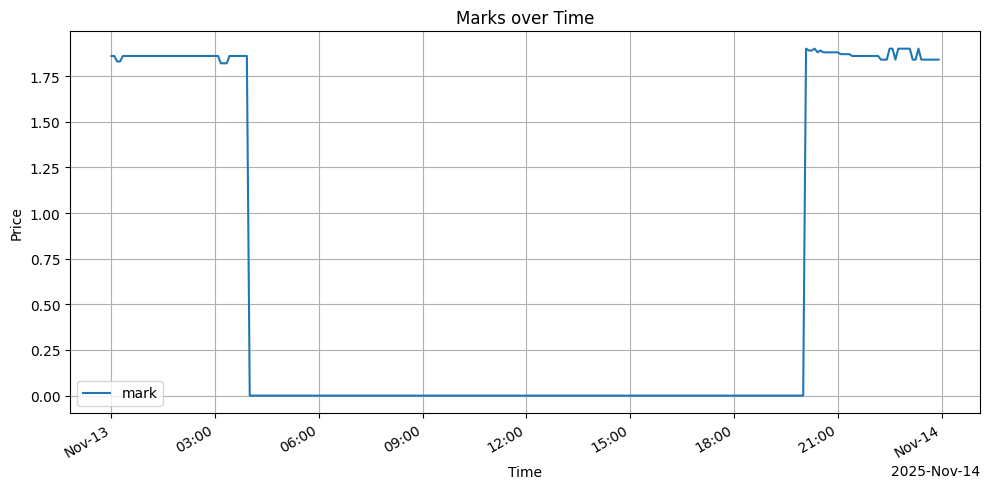

In [90]:
DAY = "2025-11-13"
IDENT = "BEEM"
VAR1 = 'extended.askPrice'
var1 = zarr_store['5m'].sel(ident=IDENT,day=DAY,qVar=VAR1)

var1['time'] = pd.to_datetime(DAY + ' ' + var1['time'].values)

plt.figure(figsize=(10,5))
var1.plot(label='mark')

plt.title("Marks over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate() # Rotate labels for readability
plt.tight_layout()
plt.show()

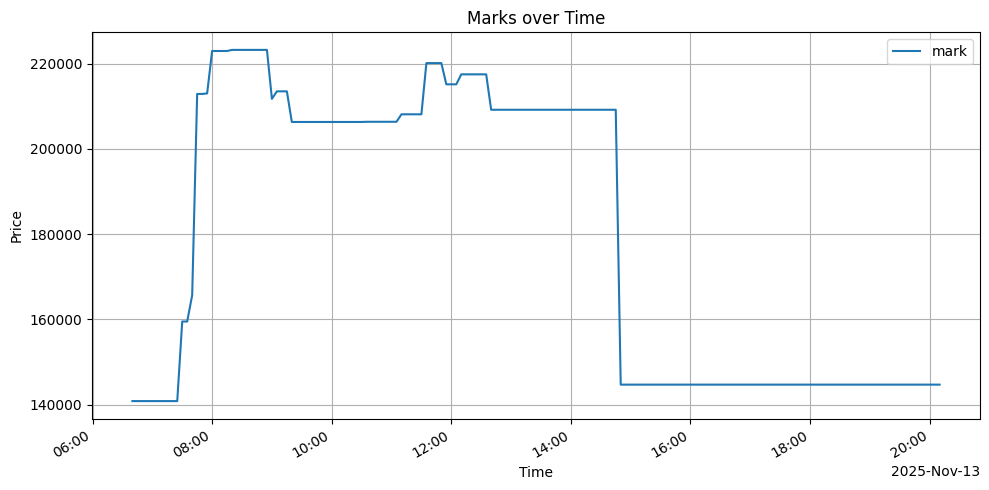

In [83]:
DAY = "2025-11-13"
IDENT = "BEEM"
VAR1 = 'reference.htbQuantity'
var1 = zarr_store['5m'].sel(ident=IDENT,day=DAY,qVar=VAR1)

var1['time'] = pd.to_datetime(DAY + ' ' + var1['time'].values)

plt.figure(figsize=(10,5))
var1.plot(label='mark')

plt.title("Marks over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate() # Rotate labels for readability
plt.tight_layout()
plt.show()